In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import re
import random
from tqdm import tqdm

In [5]:
import tensorflow as tf
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import urllib
from tensorflow.keras.preprocessing.image import array_to_img
from tensorflow.keras.preprocessing.image import img_to_array
from keras.applications.imagenet_utils import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from collections import Counter, defaultdict
from keras.utils import get_file
import json
from IPython.display import Image, display, clear_output

In [6]:
train_damaged_list = os.listdir('/Users/deepak/Music/dataset/data1a/training/00-damage')
train_not_damaged_list = os.listdir('/Users/deepak/Music/dataset/data1a/training/01-whole')
test_damaged_list = os.listdir('/Users/deepak/Music/dataset/data1a/validation/00-damage')
test_not_damaged_list = os.listdir('/Users/deepak/Music/dataset/data1a/validation/01-whole')

In [7]:
def img_shapes(files,path):
    shapes = []
    for i in files:
        img = cv2.imread(path+'/'+i)
        shapes.append(img.shape)
    return shapes

In [8]:
classes = ['Damaged','Not Damaged']
train_dmg = img_shapes(train_damaged_list,'/Users/deepak/Music/dataset/data1a/training/00-damage')
train_no_dmg = img_shapes(train_not_damaged_list,'/Users/deepak/Music/dataset/data1a/training/01-whole')
train_df = pd.DataFrame(list(zip(train_dmg,train_no_dmg)),columns = classes)

In [9]:
lists = [['damaged','not_damaged'],['front','rear','side'],['minor','moderate','severe']]
data = ['data_1','data_2','data_3']

In [10]:
paths=[]
def create_folders(name, class_lists, data):
    # Create the main folder if it doesn't exist
    os.makedirs(name, exist_ok=True)
    
    for i in range(3):  # Loop through `data`
        os.makedirs(f"{name}/{data[i]}", exist_ok=True)
        for j in ['train', 'test']:
            temp_paths = []
            os.makedirs(f"{name}/{data[i]}/{j}", exist_ok=True)
            for k in class_lists[i]:  # Loop through `class_lists`
                folder_path = f"{name}/{data[i]}/{j}/{k}"
                os.makedirs(folder_path, exist_ok=True)
                temp_paths.append(folder_path)  # Add to temp paths
            paths.append(temp_paths)  # Append to global paths list

In [11]:
create_folders('/Users/deepak/Music/dataset/data1a/file1',lists,data)

In [12]:
train_save_path_1 = paths[0][0]
train_save_path_2 = paths[0][1]
test_save_path_1 = paths[1][0]
test_save_path_2 = paths[1][1]
print(train_save_path_1)
print(train_save_path_2)
print(test_save_path_1)
print(test_save_path_2)

/Users/deepak/Music/dataset/data1a/file1/data_1/train/damaged
/Users/deepak/Music/dataset/data1a/file1/data_1/train/not_damaged
/Users/deepak/Music/dataset/data1a/file1/data_1/test/damaged
/Users/deepak/Music/dataset/data1a/file1/data_1/test/not_damaged


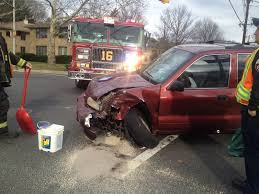

In [13]:
sample_file = random.choice(train_damaged_list)
rotation = random.randint(-20,20)
augmentation = ImageDataGenerator(rotation_range=rotation,horizontal_flip=True)
sample_img = image.load_img('/Users/deepak/Music/dataset/data1a/training/00-damage'+'/'+sample_file)
sample_img

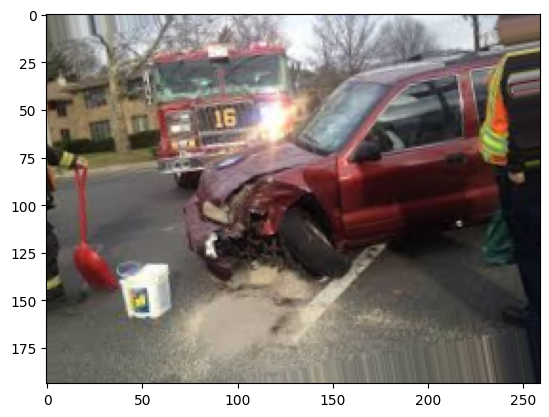

In [14]:
sample_img_array = image.img_to_array(sample_img)
sample_img_array = sample_img_array.reshape((1,) + sample_img_array.shape)
samples = []
for arr,val in zip(augmentation.flow(sample_img_array, batch_size=1, save_format='jpg'),range(1)):
    img_save = image.array_to_img(arr[0], scale=False)
    samples.append(img_save)
plt.imshow(samples[0])


In [15]:
def create_images(name,save_path,image_path):
    rotation = random.randint(-20,20)
    augmentation = ImageDataGenerator(rotation_range=rotation,horizontal_flip=True)
    
    image_org = image.load_img(image_path+'/'+name)
    
    image_org.save(save_path+'/'+name)
    
    image_arr = image.img_to_array(image_org)
    
    image_arr = image_arr.reshape((1,) + image_arr.shape)
    
    for arr,val in zip(augmentation.flow(image_arr, batch_size=1, save_format='jpeg'),range(1)):
        name = name.split('.')[0]
        img_save = image.array_to_img(arr[0], scale=False)
        img_save.save(save_path+'/'+name+'_aug_'+str(val)+'.jpeg')
    return paths

In [16]:
def save_images(name,save_path,image_path):
    image_org = image.load_img(image_path+'/'+name)
    image_org.save(save_path+'/'+name)

In [17]:
for i in tqdm(train_damaged_list):
    create_images(i,train_save_path_1,'/Users/deepak/Music/dataset/data1a/training/00-damage')
for i in tqdm(train_not_damaged_list):
    create_images(i,train_save_path_2,'/Users/deepak/Music/dataset/data1a/training/01-whole')
for i in tqdm(test_damaged_list):
    save_images(i,test_save_path_1,'/Users/deepak/Music/dataset/data1a/validation/00-damage')
for i in tqdm(test_not_damaged_list):
    save_images(i,test_save_path_2,'/Users/deepak/Music/dataset/data1a/validation/01-whole')

100%|████████████████████████████████████████████████████████████████████████████████| 230/230 [00:04<00:00, 47.23it/s]


In [18]:
data_1_files = len(os.listdir('/Users/deepak/Music/dataset/data1a/file1/data_1/train/damaged'))+len(os.listdir('/Users/deepak/Music/dataset/data1a/file1/data_1/train/not_damaged'))
print('Number of files for all classes damaged, not damaged is ',data_1_files)

Number of files for all classes damaged, not damaged is  3680


#Model(keras)

In [20]:
from tensorflow.keras.applications.resnet50 import ResNet50
from keras.applications.inception_v3 import InceptionV3
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import decode_predictions as vdecode_predictions
from tensorflow.keras.applications.resnet50 import decode_predictions as rdecode_predictions
from keras.applications.inception_v3 import decode_predictions as idecode_predictions

In [21]:
# from Keras GitHub  
def get_predictions(preds, top=5):
    global CLASS_INDEX
    if len(preds.shape) != 2 or preds.shape[1] != 1000:
        raise ValueError('`decode_predictions` expects '
                         'a batch of predictions '
                         '(i.e. a 2D array of shape (samples, 1000)). '
                         'Found array with shape: ' + str(preds.shape))
    if CLASS_INDEX is None:
        fpath = get_file('imagenet_class_index.json',
                         CLASS_INDEX_PATH,
                         cache_subdir='models')
        CLASS_INDEX = json.load(open(fpath))
    results = []
    for pred in preds:
        top_indices = pred.argsort()[-top:][::-1]
        # print('<<<<<<<<')
        # print(top_indices)
        # print('>>>>>>>>>')
        result = [tuple(CLASS_INDEX[str(i)]) + (pred[i],) for i in top_indices]
        result.sort(key=lambda x: x[2], reverse=True)
        results.append(result)
    return results

In [22]:
CLASS_INDEX = None
CLASS_INDEX_PATH = 'https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json'

In [23]:
def prepare_image(img_path):
    img = load_img(img_path, target_size=(224, 224))
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return x

In [24]:
def get_car_categories(model,pred):
    d = defaultdict(float)
    img_list = os.listdir('/Users/deepak/Music/dataset/data1a/training/01-whole')
    for i, img_path in enumerate(img_list):
        img = prepare_image('/Users/deepak/Music/dataset/data1a/training/01-whole/'+img_path)
        print(img_path)
        out = model.predict(img)
        label = pred(out)
        # retrieve the most likely result, e.g. highest probability
        label = label[0][0]
        # print the classification
        print('%s (%.2f%%)' % (label[1], label[2]*100))
        top = get_predictions(out, top=5)
        # print(top)
        for j in top[0]:
            d[j[0:2]] += j[2]
        # if(i==20):
        #   break    
        
    return Counter(d)

In [25]:
vgg16 = VGG16(weights='imagenet')
cat_counter = get_car_categories(vgg16,vdecode_predictions)

0001.jpg
1/1 [==============================] - 1s 1s/step
snowplow (38.04%)
0002.jpg
1/1 [==============================] - 0s 281ms/step
ambulance (33.71%)
0003.jpg
1/1 [==============================] - 0s 197ms/step
jeep (85.03%)
0004.jpg
1/1 [==============================] - 0s 238ms/step
jeep (98.44%)
0005.jpg
1/1 [==============================] - 0s 265ms/step
half_track (30.02%)
0006.jpg
1/1 [==============================] - 0s 235ms/step
beach_wagon (63.24%)
0007.jpg
1/1 [==============================] - 0s 222ms/step
sports_car (35.89%)
0008.jpg
1/1 [==============================] - 0s 213ms/step
beach_wagon (29.05%)
0009.jpg
1/1 [==============================] - 0s 211ms/step
sports_car (44.33%)
0010.jpg
1/1 [==============================] - 0s 212ms/step
convertible (36.89%)
0011.jpg
1/1 [==============================] - 0s 214ms/step
minivan (33.54%)
0012.jpg
1/1 [==============================] - 0s 215ms/step
sports_car (41.78%)
0013.jpg
1/1 [====================

In [26]:
cat_list = [k for k, v in cat_counter.most_common()[:20]]


In [46]:
import pickle as pk

try:
    with open('cat_counter.pk', 'wb') as f:
        pk.dump(cat_counter, f, -1)
    print("Saved successfully!")
except Exception as e:
    print("Failed to save:", e)


Saved successfully!


In [48]:
import os
print(os.listdir())  # Shows all files in current directory


['.ipynb_checkpoints', '02_second_gate_damaged_or_whole.ipynb', '1car_or_not-Copy1.ipynb', '1car_or_not.ipynb', '2.0', '2damage_exists.ipynb', '3-damage_location(rear,sider front).ipynb', '4_Damage_severity-Copy1.ipynb', '4_Damage_severity.ipynb', '5allcombined.ipynb', 'assets', 'base_line_vs_transfer_learning.ipynb', 'car-damage-detection.ipynb', 'cat_counter.pk', 'custom.py', 'dataset', 'debug.log', 'introduction.docx', 'logs', 'MANIFEST.in', 'media', 'mrcnn', 'README.md', 'requirements.txt', 'samples', 'save.jpg', 'setup.cfg', 'setup.py', 'temp_image.jpg', 'training_cmd.txt', 'vgg16_cat_list.pk', '__pycache__']


In [44]:
with open('cat_counter.pk', 'rb') as f:
    cat_counter = pk.load(f)

In [38]:
def validate(image_path):
    print(image_path)
    image_path='/Users/deepak/Music/dataset/sample/'+image_path
    img = prepare_image(image_path)
    out = vgg16.predict(img)
   
    display(Image(image_path))
   
    top = get_predictions(out, top=5)
    print(top[0])
    # for j in top[0]:
    if top[0][0][0:2] in cat_list:
        return( "IMAGE IS A CAR")
           
    return("IMAGE IS NOT A CAR")

0001.jpg
1/1 [==============================] - 2s 2s/step


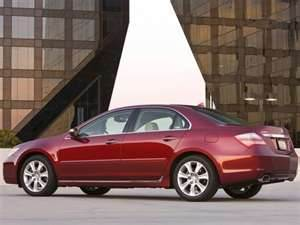

[('n02814533', 'beach_wagon', 0.27123374), ('n03770679', 'minivan', 0.12772477), ('n04285008', 'sports_car', 0.10871203), ('n03100240', 'convertible', 0.067842714), ('n02974003', 'car_wheel', 0.049270704)]
IMAGE IS A CAR

0002.jpg
1/1 [==============================] - 0s 253ms/step


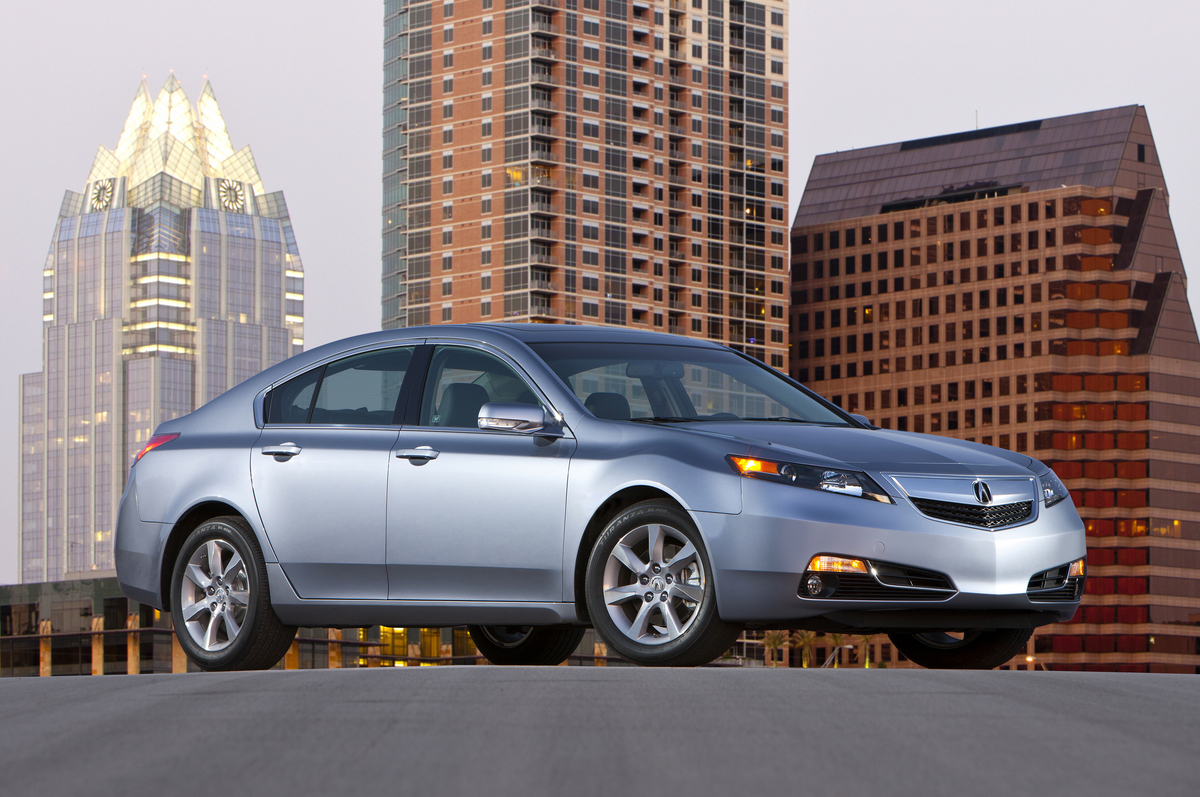

[('n04285008', 'sports_car', 0.3149368), ('n04037443', 'racer', 0.30839533), ('n02930766', 'cab', 0.124563895), ('n02814533', 'beach_wagon', 0.06075491), ('n03670208', 'limousine', 0.049448114)]
IMAGE IS A CAR

0003.jpg
1/1 [==============================] - 0s 211ms/step


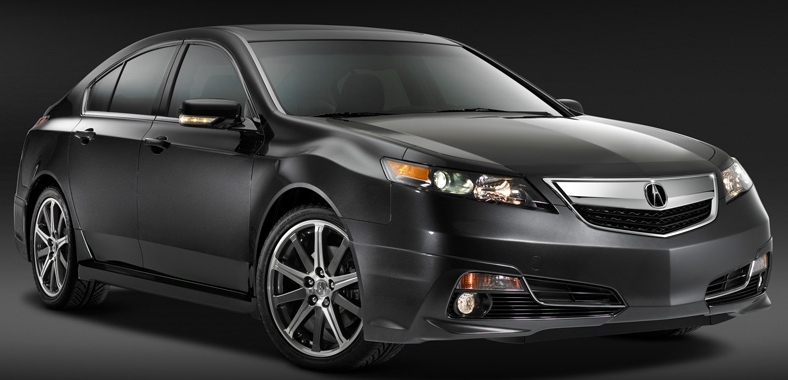

[('n02814533', 'beach_wagon', 0.3696195), ('n04285008', 'sports_car', 0.31518054), ('n03459775', 'grille', 0.15655869), ('n03770679', 'minivan', 0.038841974), ('n04037443', 'racer', 0.036172744)]
IMAGE IS A CAR

house.jpg
1/1 [==============================] - 0s 215ms/step


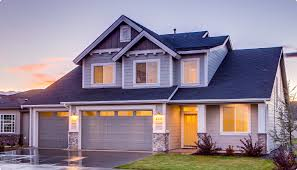

[('n03930313', 'picket_fence', 0.32203087), ('n02859443', 'boathouse', 0.26767278), ('n03028079', 'church', 0.10002382), ('n03776460', 'mobile_home', 0.08537901), ('n09193705', 'alp', 0.030957049)]
IMAGE IS NOT A CAR

IMG-20241204-WA0002.jpg
1/1 [==============================] - 0s 241ms/step


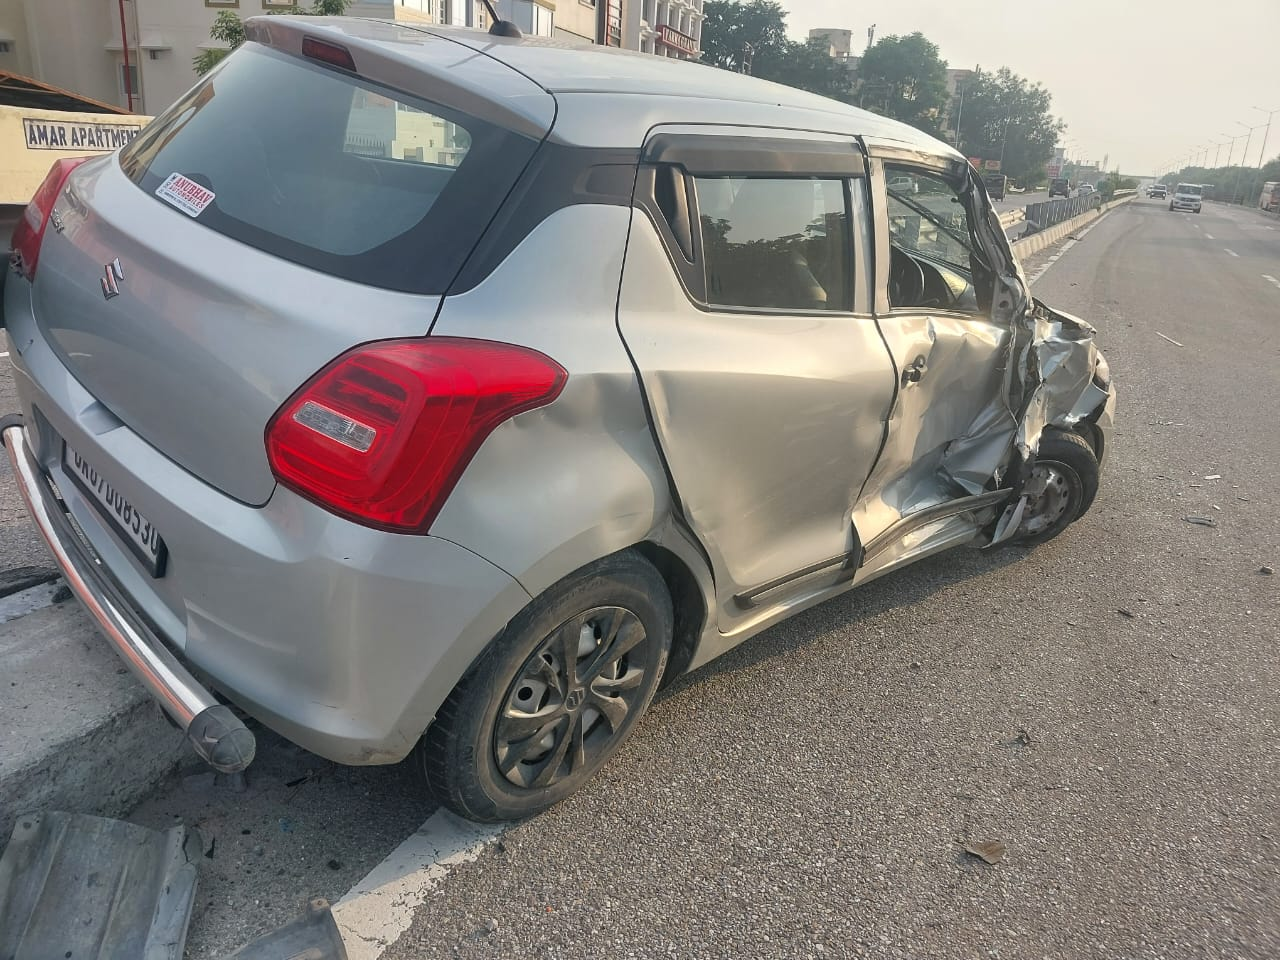

[('n03770679', 'minivan', 0.32751974), ('n03100240', 'convertible', 0.09872471), ('n02814533', 'beach_wagon', 0.08087046), ('n03594945', 'jeep', 0.069275945), ('n03791053', 'motor_scooter', 0.056473047)]
IMAGE IS A CAR

IMG-20241204-WA0008.jpg
1/1 [==============================] - 0s 218ms/step


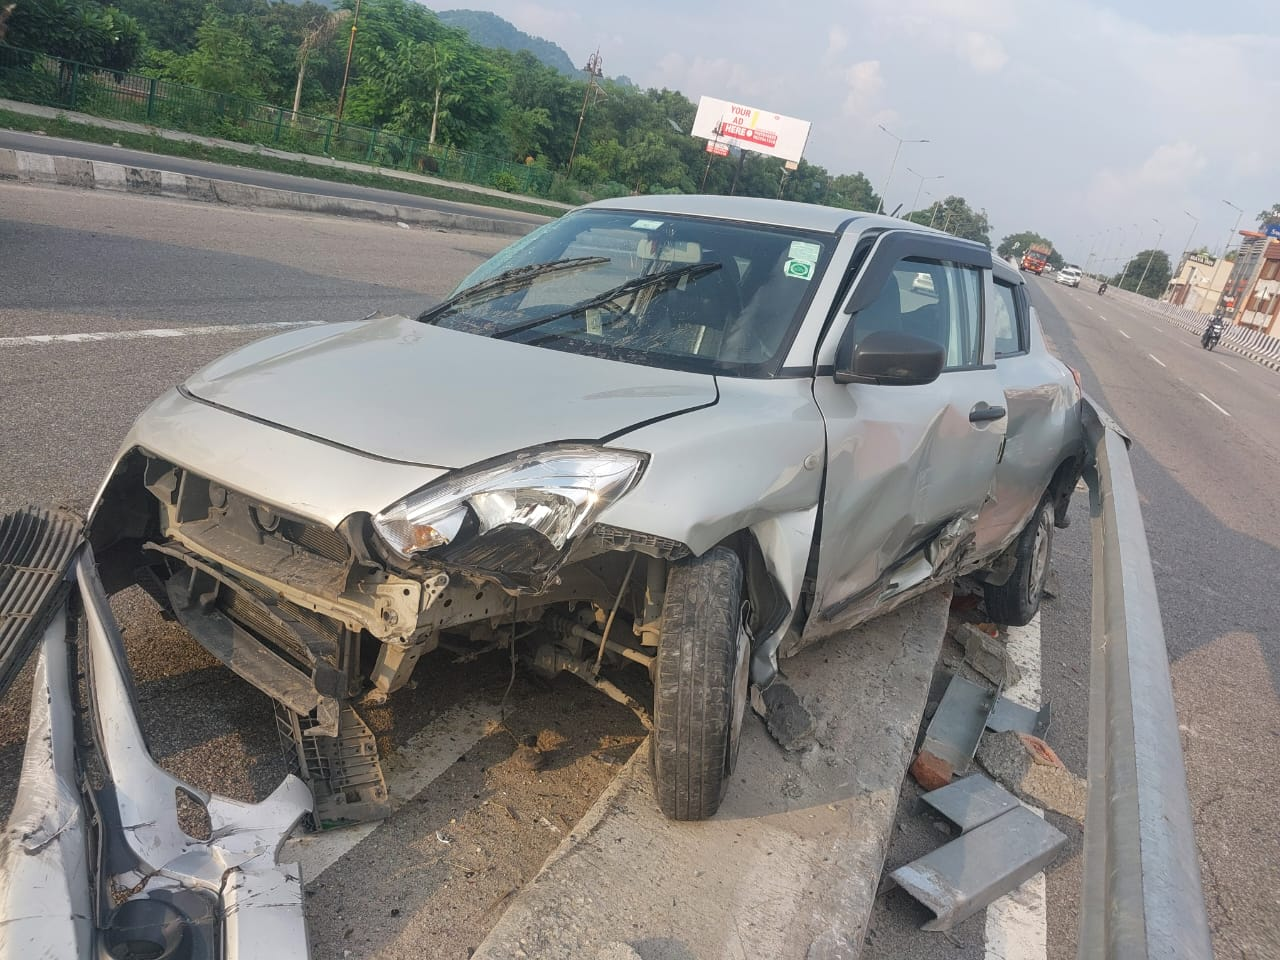

[('n03594945', 'jeep', 0.45255792), ('n03670208', 'limousine', 0.059247922), ('n04461696', 'tow_truck', 0.04580932), ('n02814533', 'beach_wagon', 0.036498975), ('n03930630', 'pickup', 0.03340817)]
IMAGE IS A CAR

tree.jpeg
1/1 [==============================] - 0s 208ms/step


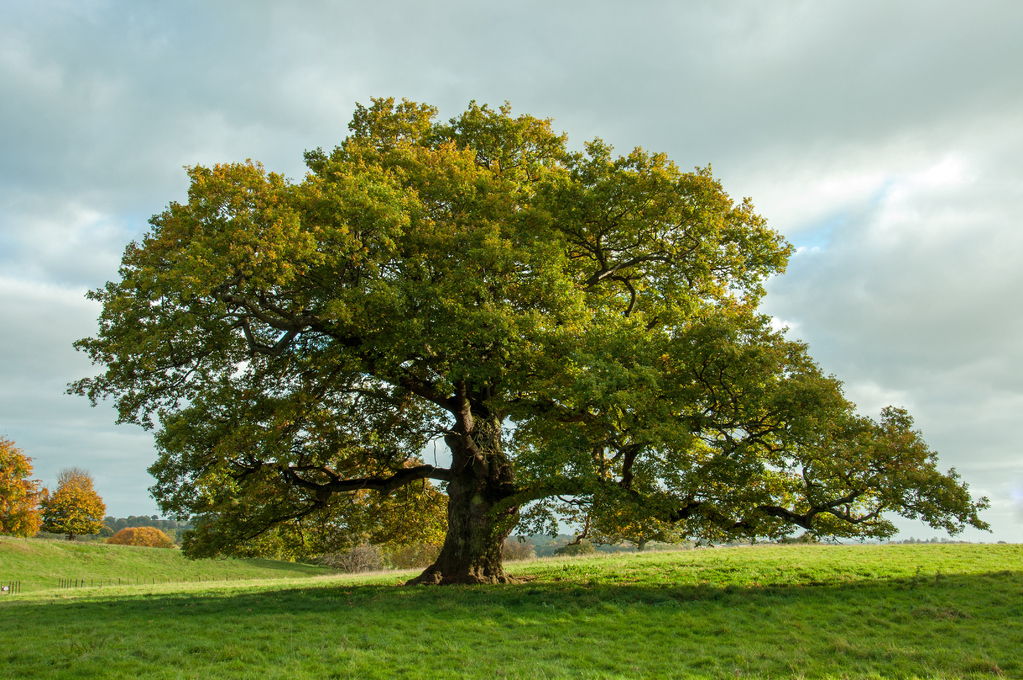

[('n03743016', 'megalith', 0.2679386), ('n11879895', 'rapeseed', 0.09669428), ('n04326547', 'stone_wall', 0.08494733), ('n07802026', 'hay', 0.07063229), ('n02793495', 'barn', 0.06071763)]
IMAGE IS NOT A CAR



In [40]:
img_list = os.listdir('/Users/deepak/Music/dataset/sample')
for i, image_path in enumerate(img_list):
  print(validate(image_path))
  print()
    
